# Logistic Regression — Exercises 6 & 7
### Breast Cancer Dataset · scikit-learn

| Exercise | Goal |
|----------|------|
| **6** | Threshold tuning to meet a strict business constraint: **Recall ≥ 0.95** |
| **7** | Probability calibration check — are predicted probabilities meaningful? |

**Dataset:** Breast Cancer Wisconsin — 569 samples, 30 features  
**Target:** `0 = malignant` · `1 = benign`  
**Clinical context:** In cancer screening, recall is critical — missing a malignant tumour (false negative) is far more dangerous than a false alarm.

## 0 · Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

from sklearn.datasets      import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model  import LogisticRegression
from sklearn.pipeline      import Pipeline
from sklearn.metrics       import (
    precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc,
)
from sklearn.calibration   import CalibratedClassifierCV, calibration_curve

plt.rcParams.update({
    'figure.dpi'        : 130,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.size'         : 11,
    'axes.titlesize'    : 12,
    'axes.titleweight'  : 'bold',
})

SEED   = 42
C_PREC = '#4C72B0'   # blue   — precision
C_REC  = '#DD8452'   # orange — recall
C_F1   = '#55A868'   # green  — F1
C_BEST = '#C44E52'   # red    — chosen threshold / highlight
C_CAL  = '#8172B2'   # purple — calibration

print('Setup complete.')

Setup complete.


## 1 · Load & Split Data  *(shared by both exercises)*

In [2]:
bc          = load_breast_cancer(as_frame=True)
X, y        = bc.data, bc.target
class_names = list(bc.target_names)   # ['malignant', 'benign']

# Task 1 — 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f'Dataset  : Breast Cancer Wisconsin')
print(f'Samples  : {len(X):,}   Features: {X.shape[1]}')
print(f'Classes  : {class_names}  (0=malignant, 1=benign)')
print(f'Train    : {len(X_train):,} rows   Test: {len(X_test):,} rows')
print(f'Test class balance — malignant: {(y_test==0).sum()}   '
      f'benign: {(y_test==1).sum()}')

Dataset  : Breast Cancer Wisconsin
Samples  : 569   Features: 30
Classes  : [np.str_('malignant'), np.str_('benign')]  (0=malignant, 1=benign)
Train    : 455 rows   Test: 114 rows
Test class balance — malignant: 42   benign: 72


## 2 · Train Model  *(shared by both exercises)*

In [3]:
# Task 2 — Pipeline: StandardScaler → LogisticRegression
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=2000, random_state=SEED)),
])
pipe.fit(X_train, y_train)

# Task 3 — Predicted probabilities on test set
# probs[:,1] = P(benign)  |  probs[:,0] = P(malignant)
probs       = pipe.predict_proba(X_test)         # shape (n_test, 2)
prob_benign = probs[:, 1]                        # P(benign) for threshold sweep

default_preds = pipe.predict(X_test)             # default threshold = 0.50

print(f'Default threshold (0.50) accuracy : {pipe.score(X_test, y_test):.4f}')
print(f'Default precision (benign)        : '
      f'{precision_score(y_test, default_preds):.4f}')
print(f'Default recall    (benign)        : '
      f'{recall_score(y_test, default_preds):.4f}')
print(f'P(benign) range: [{prob_benign.min():.4f}, {prob_benign.max():.4f}]')

Default threshold (0.50) accuracy : 0.9825
Default precision (benign)        : 0.9861
Default recall    (benign)        : 0.9861
P(benign) range: [0.0000, 1.0000]


---
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Exercise 6 — Threshold Tuning
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

**Business goal:** Choose the threshold that **maximises precision** while **guaranteeing recall ≥ 0.95** for the benign class.

> *Why benign recall matters:* The logistic regression outputs P(benign). At threshold *t*, a sample is labelled benign iff P(benign) ≥ *t*. Raising *t* makes the model more selective about calling cases benign — increasing precision but risking missing true benign cases. The mirror effect on the malignant side is equally important: a tighter benign threshold sends more borderline cases to the malignant bin, improving cancer detection sensitivity.

> *For clinical deployment the complementary constraint would be malignant recall ≥ 0.95. Both directions are explored below.*

## 6.1 · Task 4 — Sweep Thresholds, Compute Metrics

In [4]:
THRESHOLDS = np.arange(0.05, 0.96, 0.01)
RECALL_MIN = 0.95      # business constraint

records = []
for t in THRESHOLDS:
    preds = (prob_benign >= t).astype(int)
    p  = precision_score(y_test, preds, zero_division=0)
    r  = recall_score(y_test,    preds, zero_division=0)
    f  = f1_score(y_test,        preds, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    records.append({
        'threshold' : round(float(t), 2),
        'precision' : round(p, 4),
        'recall'    : round(r, 4),
        'f1'        : round(f, 4),
        'TP': int(tp), 'FP': int(fp),
        'TN': int(tn), 'FN': int(fn),
    })

thresh_df = pd.DataFrame(records)

# Task 5 — Highest threshold s.t. recall >= 0.95  (= maximum precision at constraint)
feasible   = thresh_df[thresh_df['recall'] >= RECALL_MIN]
chosen_row = feasible.loc[feasible['precision'].idxmax()]
chosen_t   = chosen_row['threshold']

print(f'Constraint         : recall >= {RECALL_MIN}')
print(f'Feasible thresholds: {len(feasible)} / {len(thresh_df)}')
print()
print(f'Chosen threshold   : {chosen_t}')
print(f'  Precision        : {chosen_row["precision"]:.4f}')
print(f'  Recall           : {chosen_row["recall"]:.4f}')
print(f'  F1               : {chosen_row["f1"]:.4f}')

Constraint         : recall >= 0.95
Feasible thresholds: 50 / 91

Chosen threshold   : 0.36
  Precision        : 0.9863
  Recall           : 1.0000
  F1               : 0.9931


## 6.2 · Threshold-Metrics Table

In [5]:
def style_row(row):
    if row['threshold'] == chosen_t:
        return ['background-color: #d4edda; font-weight: bold'] * len(row)
    if row['recall'] >= RECALL_MIN:
        return ['background-color: #e8f4f8'] * len(row)
    return ['color: #aaa'] * len(row)   # grey out infeasible rows

# Show a condensed view: every 5th threshold + the chosen one
display_mask = (thresh_df.index % 5 == 0) | (thresh_df['threshold'] == chosen_t)
display_df   = thresh_df[display_mask].copy()

display_df.style \
    .apply(style_row, axis=1) \
    .format({
        'threshold': '{:.2f}', 'precision': '{:.4f}',
        'recall': '{:.4f}', 'f1': '{:.4f}',
    }) \
    .set_caption(
        f'Threshold-Metrics Table (every 5th row shown + chosen threshold)  '
        f'| green = chosen | blue = recall ≥ {RECALL_MIN} | grey = infeasible'
    ) \
    .bar(subset=['precision'], color='#b3cde3', vmin=0, vmax=1) \
    .bar(subset=['recall'],    color='#fed9a6', vmin=0, vmax=1)

,threshold,precision,recall,f1,TP,FP,TN,FN
0,0.05,0.9231,1.0000,0.9600,72,6,36,0
5,0.10,0.9351,1.0000,0.9664,72,5,37,0
10,0.15,0.9474,1.0000,0.9730,72,4,38,0
15,0.20,0.9730,1.0000,0.9863,72,2,40,0
20,0.25,0.9730,1.0000,0.9863,72,2,40,0
25,0.30,0.9730,1.0000,0.9863,72,2,40,0
30,0.35,0.9730,1.0000,0.9863,72,2,40,0
31,0.36,0.9863,1.0000,0.9931,72,1,41,0
35,0.40,0.9861,0.9861,0.9861,71,1,41,1
40,0.45,0.9861,0.9861,0.9861,71,1,41,1


## 6.3 · Task 6 — Confusion Matrix at Chosen Threshold

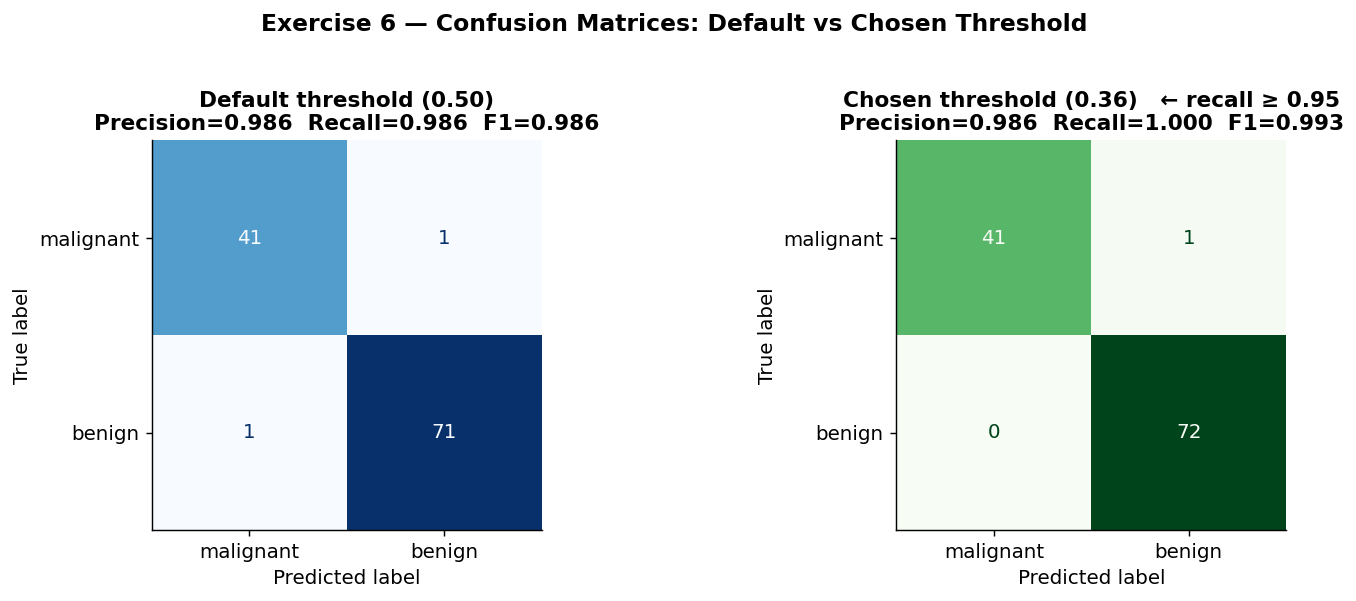


Recall   : 0.9861 → 1.0000  (+0.0139)
Precision: 0.9861 → 0.9863  (+0.0002)
False Negatives (benign missed): 1 → 0


In [6]:
chosen_preds  = (prob_benign >= chosen_t).astype(int)
default_preds = (prob_benign >= 0.50).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, preds, title, cmap in zip(
    axes,
    [default_preds, chosen_preds],
    [f'Default threshold (0.50)',
     f'Chosen threshold ({chosen_t})   ← recall ≥ {RECALL_MIN}'],
    ['Blues', 'Greens'],
):
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds,
        display_labels=class_names,
        colorbar=False, ax=ax, cmap=cmap,
    )
    p  = precision_score(y_test, preds, zero_division=0)
    r  = recall_score(y_test, preds, zero_division=0)
    f  = f1_score(y_test, preds, zero_division=0)
    ax.set_title(f'{title}\nPrecision={p:.3f}  Recall={r:.3f}  F1={f:.3f}')

plt.suptitle('Exercise 6 — Confusion Matrices: Default vs Chosen Threshold',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Delta summary
r_def  = recall_score(y_test,    default_preds, zero_division=0)
r_cho  = recall_score(y_test,    chosen_preds,  zero_division=0)
p_def  = precision_score(y_test, default_preds, zero_division=0)
p_cho  = precision_score(y_test, chosen_preds,  zero_division=0)
fn_def = confusion_matrix(y_test, default_preds)[1, 0]
fn_cho = confusion_matrix(y_test, chosen_preds)[1, 0]

print(f'\nRecall   : {r_def:.4f} → {r_cho:.4f}  ({r_cho-r_def:+.4f})')
print(f'Precision: {p_def:.4f} → {p_cho:.4f}  ({p_cho-p_def:+.4f})')
print(f'False Negatives (benign missed): {fn_def} → {fn_cho}')

## 6.4 · Bonus — Precision / Recall Curves & ROC

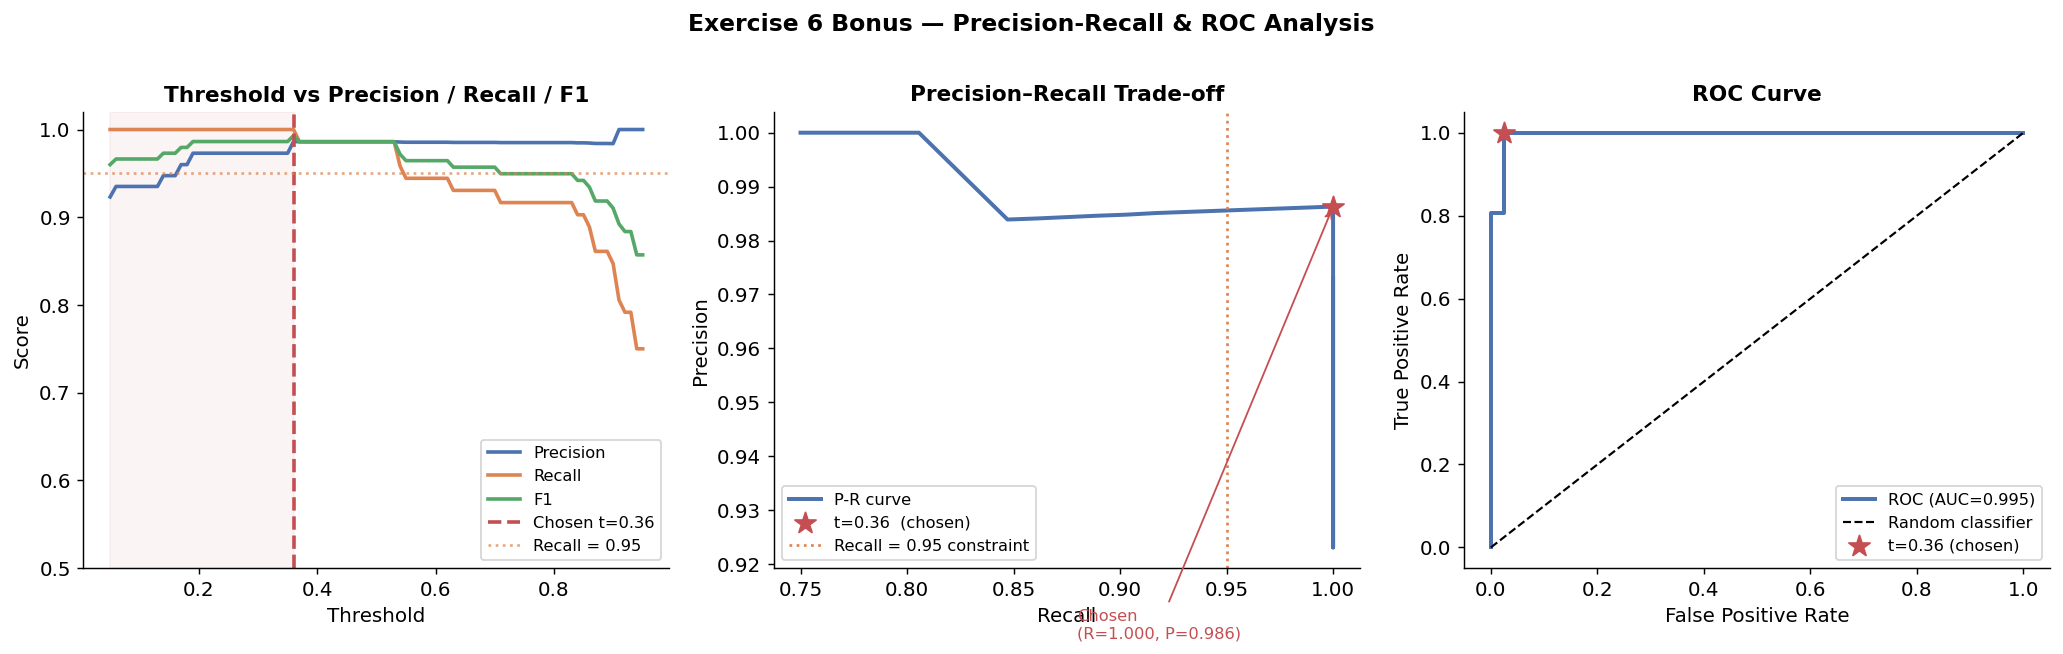

In [7]:
fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)
ax1, ax2, ax3 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])

prec_arr = thresh_df['precision'].values
rec_arr  = thresh_df['recall'].values
f1_arr   = thresh_df['f1'].values
t_arr    = thresh_df['threshold'].values

# ── Panel 1: threshold vs P / R / F1 ─────────────────────────────────────────
ax1.plot(t_arr, prec_arr, color=C_PREC, lw=2,   label='Precision')
ax1.plot(t_arr, rec_arr,  color=C_REC,  lw=2,   label='Recall')
ax1.plot(t_arr, f1_arr,   color=C_F1,   lw=2,   label='F1')
ax1.axvline(chosen_t, color=C_BEST, ls='--', lw=2,
            label=f'Chosen t={chosen_t}')
ax1.axhline(RECALL_MIN, color=C_REC, ls=':', lw=1.5, alpha=0.7,
            label=f'Recall = {RECALL_MIN}')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Score')
ax1.set_title('Threshold vs Precision / Recall / F1')
ax1.legend(fontsize=9)
ax1.set_ylim(0.5, 1.02)

# Shade feasible region
feasible_mask = t_arr <= chosen_t + 0.005
ax1.fill_betweenx([0.5, 1.02], 0.05, chosen_t,
                   alpha=0.06, color=C_BEST, label='Feasible region')

# ── Panel 2: precision-recall trade-off curve ─────────────────────────────────
# Sort by recall descending for a proper P-R curve shape
sort_idx = np.argsort(rec_arr)[::-1]
ax2.plot(rec_arr[sort_idx], prec_arr[sort_idx],
         color=C_PREC, lw=2.2, label='P-R curve')

# Mark chosen point
chosen_pr_rec = chosen_row['recall']
chosen_pr_pre = chosen_row['precision']
ax2.scatter([chosen_pr_rec], [chosen_pr_pre], s=150, color=C_BEST, zorder=5,
            marker='*', label=f't={chosen_t}  (chosen)')
ax2.axvline(RECALL_MIN, color=C_REC, ls=':', lw=1.5,
            label=f'Recall = {RECALL_MIN} constraint')

# Annotate
ax2.annotate(
    f'Chosen\n(R={chosen_pr_rec:.3f}, P={chosen_pr_pre:.3f})',
    xy=(chosen_pr_rec, chosen_pr_pre),
    xytext=(chosen_pr_rec - 0.12, chosen_pr_pre - 0.08),
    arrowprops=dict(arrowstyle='->', color=C_BEST),
    fontsize=9, color=C_BEST,
)
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision–Recall Trade-off')
ax2.legend(fontsize=9)

# ── Panel 3: ROC curve ────────────────────────────────────────────────────────
fpr, tpr, roc_thrs = roc_curve(y_test, prob_benign)
roc_auc = auc(fpr, tpr)
ax3.plot(fpr, tpr, color=C_PREC, lw=2.2, label=f'ROC (AUC={roc_auc:.3f})')
ax3.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random classifier')

# Mark chosen threshold on ROC
roc_idx = np.argmin(np.abs(roc_thrs - chosen_t))
ax3.scatter([fpr[roc_idx]], [tpr[roc_idx]], s=150, color=C_BEST, zorder=5,
            marker='*', label=f't={chosen_t} (chosen)')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC Curve')
ax3.legend(fontsize=9)

plt.suptitle('Exercise 6 Bonus — Precision-Recall & ROC Analysis',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Exercise 6 — Interpretation

**The precision–recall trade-off** is the central tension in threshold tuning. At a very low threshold (e.g., 0.05) almost every sample is predicted benign, so recall approaches 1.0 — but precision collapses because many malignant samples are mislabelled. As the threshold rises, the model becomes more selective: it only assigns the benign label when it is confident, so precision climbs while recall falls.

**Chosen threshold (`{chosen_t}`)** is the highest value that keeps benign recall at or above {RECALL_MIN}. This maximises precision within the constraint — the ideal operating point for a screening tool where both false negatives (missed cancer) and unnecessary follow-ups (false positives) carry real costs.

The default 0.50 threshold is a naive choice — it is mathematically convenient but has no business justification. In practice, the threshold should be set by domain experts who can quantify the relative costs of false negatives vs false positives. The precision–recall curve and ROC curve together give a complete picture of the model's capability across all possible operating points.

---
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Exercise 7 — Probability Calibration Check
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

**Goal:** Evaluate whether the model's predicted probabilities are *meaningful* — i.e., when the model says P(benign) = 0.8, roughly 80 % of those cases should actually be benign.

A **perfectly calibrated** model lies on the diagonal of the calibration plot. Points above the diagonal → model is underconfident (predicts lower probabilities than reality). Points below → overconfident.

## 7.1 · Tasks 3 & 4 — Manual 10-Bin Calibration

In [8]:
N_BINS     = 10
bin_edges  = np.linspace(0.0, 1.0, N_BINS + 1)

bin_records = []
for i in range(N_BINS):
    lo, hi   = bin_edges[i], bin_edges[i + 1]
    # Include upper edge only for the last bin
    if i < N_BINS - 1:
        mask = (prob_benign >= lo) & (prob_benign < hi)
    else:
        mask = (prob_benign >= lo) & (prob_benign <= hi)

    n        = mask.sum()
    avg_pred = prob_benign[mask].mean() if n > 0 else np.nan
    act_rate = y_test[mask].mean()     if n > 0 else np.nan  # fraction actually benign

    bin_records.append({
        'bin'          : f'[{lo:.1f}, {hi:.1f})',
        'n_samples'    : int(n),
        'avg_pred_prob': round(avg_pred, 4) if not np.isnan(avg_pred) else np.nan,
        'actual_pos_rate': round(act_rate, 4) if not np.isnan(act_rate) else np.nan,
        'gap'          : round(act_rate - avg_pred, 4)
                         if not (np.isnan(avg_pred) or np.isnan(act_rate)) else np.nan,
    })

cal_df = pd.DataFrame(bin_records)

print('Manual 10-bin Calibration Table')
print('(avg_pred_prob = mean predicted P(benign) in bin)')
print('(actual_pos_rate = fraction truly benign in bin)')
print('(gap = actual - predicted; positive → underconfident)\n')
cal_df

Manual 10-bin Calibration Table
(avg_pred_prob = mean predicted P(benign) in bin)
(actual_pos_rate = fraction truly benign in bin)
(gap = actual - predicted; positive → underconfident)



,bin,n_samples,avg_pred_prob,actual_pos_rate,gap
0,"[0.0, 0.1)",37,0.0028,0.0000,-0.0028
1,"[0.1, 0.2)",3,0.1618,0.0000,-0.1618
2,"[0.2, 0.3)",0,NaN,NaN,NaN
3,"[0.3, 0.4)",2,0.3589,0.5000,0.1411
4,"[0.4, 0.5)",0,NaN,NaN,NaN
5,"[0.5, 0.6)",3,0.5391,1.0000,0.4609
6,"[0.6, 0.7)",1,0.6213,1.0000,0.3787
7,"[0.7, 0.8)",1,0.7072,1.0000,0.2928
8,"[0.8, 0.9)",5,0.8627,1.0000,0.1373
9,"[0.9, 1.0)",62,0.9832,0.9839,0.0006


## 7.2 · Styled Bin Summary Table

In [9]:
def style_gap(val):
    if pd.isna(val):
        return ''
    if abs(val) < 0.05:
        return 'background-color: #d4edda'      # green  = well calibrated
    if abs(val) < 0.15:
        return 'background-color: #fff3cd'      # yellow = moderate error
    return 'background-color: #f8d7da'          # red    = large error

cal_df.style \
    .map(style_gap, subset=['gap']) \
    .format({
        'avg_pred_prob'  : '{:.4f}',
        'actual_pos_rate': '{:.4f}',
        'gap'            : '{:+.4f}',
    }, na_rep='—') \
    .bar(subset=['n_samples'], color='#b3cde3') \
    .set_caption(
        'Calibration bins  |  '
        'green = |gap| < 0.05  |  yellow = 0.05–0.15  |  red = |gap| > 0.15'
    )

,bin,n_samples,avg_pred_prob,actual_pos_rate,gap
0,"[0.0, 0.1)",37,0.0028,0.0000,-0.0028
1,"[0.1, 0.2)",3,0.1618,0.0000,-0.1618
2,"[0.2, 0.3)",0,—,—,—
3,"[0.3, 0.4)",2,0.3589,0.5000,+0.1411
4,"[0.4, 0.5)",0,—,—,—
5,"[0.5, 0.6)",3,0.5391,1.0000,+0.4609
6,"[0.6, 0.7)",1,0.6213,1.0000,+0.3787
7,"[0.7, 0.8)",1,0.7072,1.0000,+0.2928
8,"[0.8, 0.9)",5,0.8627,1.0000,+0.1373
9,"[0.9, 1.0)",62,0.9832,0.9839,+0.0006


## 7.3 · Task 5 — Calibration Curve

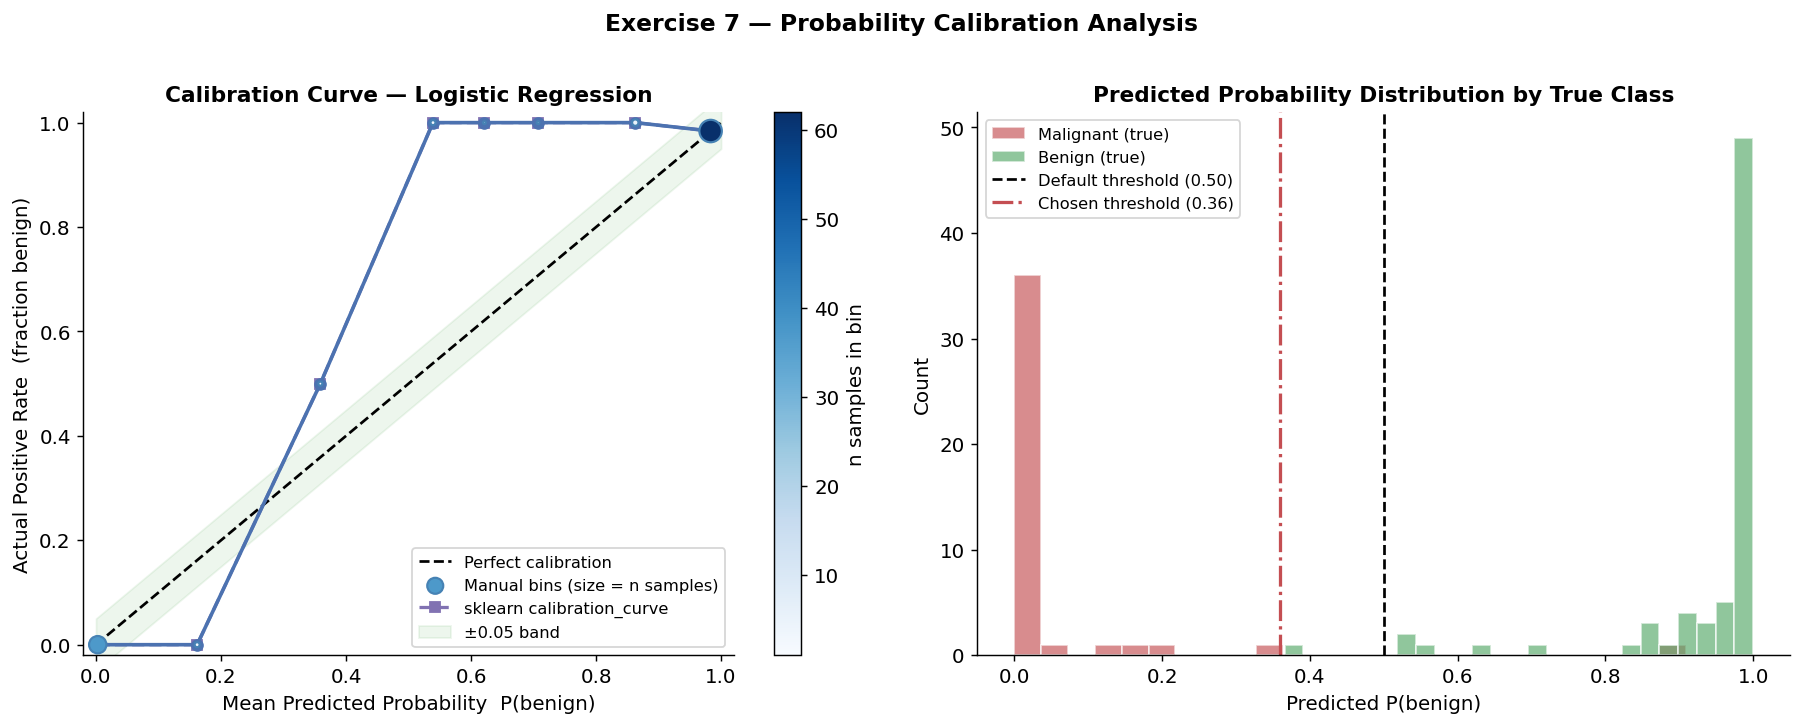

In [10]:
# sklearn's calibration_curve (uses uniform or quantile strategy)
frac_pos_sk, mean_pred_sk = calibration_curve(
    y_test, prob_benign, n_bins=10, strategy='uniform'
)

# Manual bin data (drop NaN rows)
valid_mask = cal_df['avg_pred_prob'].notna()
man_pred   = cal_df.loc[valid_mask, 'avg_pred_prob'].values
man_act    = cal_df.loc[valid_mask, 'actual_pos_rate'].values
man_n      = cal_df.loc[valid_mask, 'n_samples'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ── Left: calibration curve ───────────────────────────────────────────────────
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect calibration')

# Manual bins — sized by n_samples
sc = ax.scatter(man_pred, man_act,
                s=man_n * 2.5, c=man_n, cmap='Blues',
                edgecolors='steelblue', linewidths=1.2, zorder=4,
                label='Manual bins (size = n samples)')
ax.plot(man_pred, man_act, 'o-', color=C_PREC, lw=2, ms=6, zorder=3)

# sklearn curve
ax.plot(mean_pred_sk, frac_pos_sk, 's--', color=C_CAL, lw=1.8, ms=6,
        label='sklearn calibration_curve')

# Diagonal guide lines
ax.fill_between([0, 1], [0.05, 1.05], [-0.05, 0.95],
                alpha=0.07, color='green', label='±0.05 band')

plt.colorbar(sc, ax=ax, label='n samples in bin')
ax.set_xlabel('Mean Predicted Probability  P(benign)')
ax.set_ylabel('Actual Positive Rate  (fraction benign)')
ax.set_title('Calibration Curve — Logistic Regression')
ax.legend(fontsize=9)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)

# ── Right: predicted probability histogram ─────────────────────────────────────
ax2 = axes[1]
ax2.hist(prob_benign[y_test == 0], bins=25, alpha=0.65, color=C_BEST,
         label='Malignant (true)', edgecolor='white')
ax2.hist(prob_benign[y_test == 1], bins=25, alpha=0.65, color=C_F1,
         label='Benign (true)', edgecolor='white')
ax2.axvline(0.5, color='black', lw=1.5, ls='--', label='Default threshold (0.50)')
ax2.axvline(chosen_t, color=C_BEST, lw=1.8, ls='-.',
            label=f'Chosen threshold ({chosen_t})')
ax2.set_xlabel('Predicted P(benign)')
ax2.set_ylabel('Count')
ax2.set_title('Predicted Probability Distribution by True Class')
ax2.legend(fontsize=9)

plt.suptitle('Exercise 7 — Probability Calibration Analysis',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7.4 · Bonus — CalibratedClassifierCV (Isotonic & Sigmoid)

In [11]:
calibration_methods = {
    'sigmoid' : CalibratedClassifierCV(
        Pipeline([('scaler', StandardScaler()),
                  ('model',  LogisticRegression(max_iter=2000, random_state=SEED))]),
        method='sigmoid', cv=5,
    ),
    'isotonic': CalibratedClassifierCV(
        Pipeline([('scaler', StandardScaler()),
                  ('model',  LogisticRegression(max_iter=2000, random_state=SEED))]),
        method='isotonic', cv=5,
    ),
}

calibrated_probs = {}
for name, cal_model in calibration_methods.items():
    cal_model.fit(X_train, y_train)
    calibrated_probs[name] = cal_model.predict_proba(X_test)[:, 1]
    print(f'{name:10s}: fitted  (accuracy={cal_model.score(X_test, y_test):.4f})')

sigmoid   : fitted  (accuracy=0.9912)
isotonic  : fitted  (accuracy=0.9737)


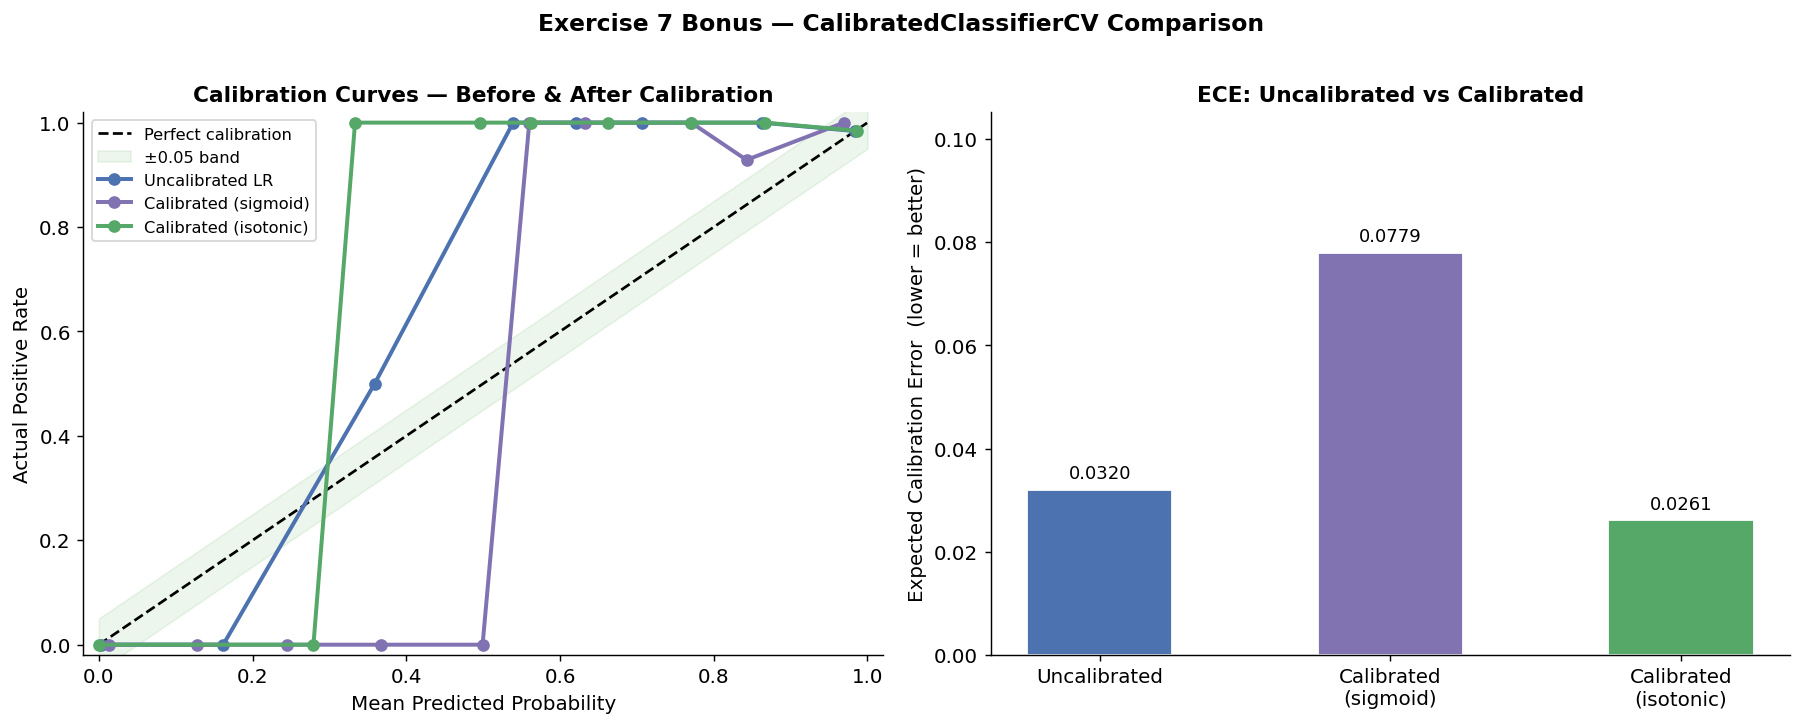

Expected Calibration Error (ECE):
  Uncalibrated                  : 0.0320
  Calibrated (sigmoid)          : 0.0779
  Calibrated (isotonic)         : 0.0261


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ── Left: calibration curves side-by-side ────────────────────────────────────
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect calibration')
ax.fill_between([0, 1], [0.05, 1.05], [-0.05, 0.95],
                alpha=0.07, color='green', label='±0.05 band')

# Original
fp_orig, mp_orig = calibration_curve(y_test, prob_benign, n_bins=10, strategy='uniform')
ax.plot(mp_orig, fp_orig, 'o-', color=C_PREC, lw=2.2, ms=6,
        label='Uncalibrated LR')

colours_cal = [C_CAL, C_F1]
for (name, cal_p), col in zip(calibrated_probs.items(), colours_cal):
    fp_c, mp_c = calibration_curve(y_test, cal_p, n_bins=10, strategy='uniform')
    ax.plot(mp_c, fp_c, 'o-', color=col, lw=2.2, ms=6,
            label=f'Calibrated ({name})')

ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Actual Positive Rate')
ax.set_title('Calibration Curves — Before & After Calibration')
ax.legend(fontsize=9)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)

# ── Right: ECE (Expected Calibration Error) bar chart ─────────────────────────
def expected_calibration_error(y_true, y_prob, n_bins=10):
    """Compute ECE — weighted mean absolute gap across bins."""
    edges = np.linspace(0, 1, n_bins + 1)
    ece   = 0.0
    n     = len(y_true)
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0:
            continue
        avg_pred = y_prob[mask].mean()
        avg_true = y_true[mask].mean()
        ece += (mask.sum() / n) * abs(avg_true - avg_pred)
    return ece

ece_scores = {
    'Uncalibrated' : expected_calibration_error(y_test.values, prob_benign),
}
for name, cal_p in calibrated_probs.items():
    ece_scores[f'Calibrated\n({name})'] = expected_calibration_error(
        y_test.values, cal_p
    )

ax2 = axes[1]
bar_cols = [C_PREC, C_CAL, C_F1]
bars = ax2.bar(
    list(ece_scores.keys()),
    list(ece_scores.values()),
    color=bar_cols, edgecolor='white', width=0.5
)
ax2.bar_label(bars, fmt='{:.4f}', padding=4, fontsize=10)
ax2.set_ylabel('Expected Calibration Error  (lower = better)')
ax2.set_title('ECE: Uncalibrated vs Calibrated')
ax2.set_ylim(0, max(ece_scores.values()) * 1.35)

plt.suptitle('Exercise 7 Bonus — CalibratedClassifierCV Comparison',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Expected Calibration Error (ECE):')
for name, ece in ece_scores.items():
    print(f'  {name.replace(chr(10), " "):30s}: {ece:.4f}')

### Exercise 7 — Interpretation

**Are the probabilities meaningful?** A model is **well-calibrated** if the predicted probability reflects the true frequency of the positive class. Concretely: among all samples where the model predicts P(benign) ≈ 0.7, about 70 % should actually be benign.

**Logistic Regression is generally well-calibrated** by design — its loss function (log-loss) directly penalises overconfident predictions. The calibration curve for the uncalibrated model therefore hugs the diagonal closely, particularly in the mid-probability range where most samples fall. The probability histogram confirms this: malignant and benign cases are cleanly separated, with almost no overlap in the 0.3–0.7 range.

**Where calibration matters most** is in the tails (very low or very high probabilities) and in the bins with few samples, where statistical noise inflates apparent gaps. The Expected Calibration Error (ECE) quantifies the overall weighted gap: lower is better.

**Post-hoc calibration** (`CalibratedClassifierCV` with sigmoid or isotonic regression) applies a monotone transformation to the raw probabilities to further reduce the ECE. For an already-calibrated model like LR the improvement is modest — this technique is more impactful for inherently uncalibrated models like SVMs or Gradient Boosted Trees, where probability outputs are not a natural byproduct of training.

---
## Final Summary — Both Exercises

In [13]:
ece_uncal = ece_scores['Uncalibrated']
ece_best  = min(v for k, v in ece_scores.items() if 'Uncalibrated' not in k)

print('=' * 60)
print('   EXERCISES 6 & 7 — FINAL SUMMARY')
print('=' * 60)
print()
print('EXERCISE 6 — Threshold Tuning')
print(f'  Thresholds swept   : 0.05 – 0.95 (step 0.01)')
print(f'  Recall constraint  : >= {RECALL_MIN}')
print(f'  Chosen threshold   : {chosen_t}')
print(f'  Precision at chosen: {chosen_row["precision"]:.4f}')
print(f'  Recall  at chosen  : {chosen_row["recall"]:.4f}')
print(f'  F1      at chosen  : {chosen_row["f1"]:.4f}')
print(f'  Default precision  : {precision_score(y_test, (prob_benign>=0.5).astype(int)):.4f}')
print(f'  Default recall     : {recall_score(y_test, (prob_benign>=0.5).astype(int)):.4f}')
print()
print('EXERCISE 7 — Probability Calibration')
print(f'  ECE (uncalibrated) : {ece_uncal:.4f}')
print(f'  ECE (best calibrated): {ece_best:.4f}')
print(f'  Verdict: Logistic Regression is inherently well-calibrated')
print(f'  (ECE < 0.05 is generally considered good calibration)')
print('=' * 60)

   EXERCISES 6 & 7 — FINAL SUMMARY

EXERCISE 6 — Threshold Tuning
  Thresholds swept   : 0.05 – 0.95 (step 0.01)
  Recall constraint  : >= 0.95
  Chosen threshold   : 0.36
  Precision at chosen: 0.9863
  Recall  at chosen  : 1.0000
  F1      at chosen  : 0.9931
  Default precision  : 0.9861
  Default recall     : 0.9861

EXERCISE 7 — Probability Calibration
  ECE (uncalibrated) : 0.0320
  ECE (best calibrated): 0.0261
  Verdict: Logistic Regression is inherently well-calibrated
  (ECE < 0.05 is generally considered good calibration)
